### Deconvolution approach to filter the noise of the data, then measuring the ARI

Imports

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance

Dataset

In [ ]:
centers = [[-4.0, 0.0], [-4.0, 3.0], [4.0, 0.0], [4.0, 3.0]]
clusters_std = [0.5, 3.0, 0.5, 3.0]

n_per_comp = [100, 100, 100, 100]

X, raw_labels = make_blobs(
    n_samples = n_per_comp,
    centers = centers,
    cluster_std = clusters_std,
    random_state = 42
)

true_labels = raw_labels // 2

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show()

Noisy dataset

In [ ]:
std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

Making the grid to evaluate the frequencies

In [8]:
T, N = 50, 2**12 #Range of frequencies, number of points in the frequency grid and point grid
t = np.linspace(-T, T, N) #Frequency grid
x_grid = np.linspace(X_obs.min(), X_obs.max(), N) #Grid of observed data points 

Making empirical characteristic function of noisy data 

In [10]:
phi_X = np.mean(np.exp(1j * np.outer(X_obs.flatten(), t)), axis=0) #Computes the empirical characteristic function of all x in X, giving a frequency domain representation of the distribution. Equation: 1/n Sigma n, i=1 (e^i*t*Xi)

phi_U = np.exp(-0.5 * (std**2) * t**2) #Computes the characteristic function for the noise model we use, since we are using gaussian noise the CF we use is e^(-1/2)*var*t^2

### Why do we want to see our distribution in the frequency domain??

The reason we want to see our distribution in the frequency domain is because the frequency domain has special properties, where for example convolution becomes multiplication

Ex: If Y is your true data and U is your noise, your observations are: X = Y + U, where the probabbility densisty function is the convolution of f(y) and f(u)

In the frequency domain X = Y + U is -> $X(t) = $Y(t) * $U(t), so if we know $X(t) and $U(t) where $U(t) is the noise distribution, we can do the opertation $Y(t) = $X(t)/$U(t) to remove the noise. Also reffered to as "Deconvolution"

Kernel window in frequency domain

Text(0.5, 0.98, 'Tricube Fourier window before and after noise')

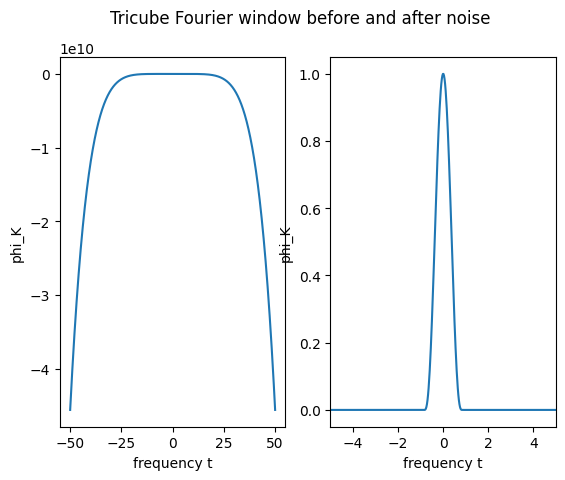

In [46]:
n = len(X_obs)
sigma_X = np.std(X_obs.flatten())
sigma_U = std
variance_diff = max(sigma_X**2 - sigma_U**2, 1e-8)
c = 1.06 #silverman's constant
h = c * np.sqrt(variance_diff) * n**(-1/5) #Controls how much smoothing is applied to our density estimate, but I do not know how to pick the optimal h, from m reserahc this seemed like the best way to do it (Silverman's rule of thumb adjsuted for deconvolution)

before_phi_K = (1 - (t*h)**2)**3
phi_K = np.zeros_like(t)
inside = np.abs(t*h) <= 1
phi_K[inside] = (1 - (t[inside]*h)**2)**3 #This computes the fourier transform of the tricube kernel, keeping all the frequencies

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(t, before_phi_K)
ax1.set_xlabel('frequency t')
ax1.set_ylabel('phi_K')

ax2.plot(t, phi_K)
ax2.set_xlim(-5, 5)
ax2.set_xlabel('frequency t')
ax2.set_ylabel('phi_K')
plt.suptitle('Tricube Fourier window before and after noise')

Form deconvolution multiplier and inverter

[nan+nanj nan+nanj nan+nanj ... nan+nanj nan+nanj nan+nanj]
[nan nan nan ... nan nan nan]


/var/folders/v8/5w6w3d096r9c_nw0xsjrrfbm0000gp/T/ipykernel_44095/2550137603.py:1: RuntimeWarning: overflow encountered in divide
  G = phi_X * phi_K / phi_U #Fourier domain estimator of the density
/var/folders/v8/5w6w3d096r9c_nw0xsjrrfbm0000gp/T/ipykernel_44095/2550137603.py:1: RuntimeWarning: invalid value encountered in divide
  G = phi_X * phi_K / phi_U #Fourier domain estimator of the density


Interpolator

Computer core distances

In [ ]:
k = 5

X_obs_fixed = X + np.random.normal(scale=std, size=X.shape)

d_obs = np.linalg.norm(
    X_obs_fixed[:, None, :] - X_obs_fixed[None, :, :],
    axis=2
)

core_dist_unc = np.zeros(n)        
for i in range(n):
    dists   = np.linalg.norm(         
        X_obs[i] - X_obs,
        axis=1
    )
    weights = fhat_interp(dists)      
    idx     = np.argsort(dists)       
    cum     = 0.0                     
    for j in idx:                     
        cum += weights[j]             
        if cum >= k:                  
            core_dist_unc[i] = dists[j]  
            break
    else:
        core_dist_unc[i] = dists[idx[-1]]

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

assert cd_i.shape == (n, 1) and cd_j.shape == (1, n)

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',     
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(labels_true=true_labels, labels_pred=pred_labels)
print("ARI (uncertainty-aware), variant 4:", ari)